In [1]:
# analyse different systems with the same spectral radius and see how the vector orthogonal to the subspace develops

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from sf_workingdir_lilly.dmlab.custom_esn_analysis import get_hidden_states_iso_feat, len_new_orth_vec, len_new_orth_vec_new_not_norm, get_time_of_threshold_crossing, exp_func, stable_trials

In [4]:
spec_rad = 1.4
time_steps = 70

Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 16
#trial=6
fixed_whh=True
fixed_wih=True

x_vals = np.arange(1,70)

In [5]:
x_vals = np.arange(1,70)
#fig, ax = plt.subplots(10,5, figsize=(25,50), sharey=True, sharex=True)

orth_vec_lens = np.zeros((50, Hippo_n_feature, time_steps-1))

for t in range(50):
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=i, weights_folder='weights_shrunk_esn_sr1.4')
        try:
            len_orth_vectors = len_new_orth_vec(hs, time_steps)
            #ax[t//5, t%5].scatter(x_vals, len_orth_vectors, label=f'{i}', s=5)
            orth_vec_lens[t, i, :] = len_orth_vectors
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for trial {t} and input neuron {i}: {e}')
            pass
        #ax[t//5, t%5].set_title(f'{t}')

In [6]:
orth_vec_lens_not_norm = np.zeros((50, Hippo_n_feature, time_steps-1))

for t in range(50):
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=i, weights_folder='weights_shrunk_esn_sr1.4')
        try:
            len_orth_vectors = len_new_orth_vec_new_not_norm(hs, time_steps)
            #ax[t//5, t%5].scatter(x_vals, len_orth_vectors, label=f'{i}', s=5)
            orth_vec_lens_not_norm[t, i, :] = len_orth_vectors
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for trial {t} and input neuron {i}: {e}')
            pass

In [7]:
thresh_crossed = get_time_of_threshold_crossing(orth_vec_lens)
print(thresh_crossed)

thresh_crossed_not_norm = get_time_of_threshold_crossing(orth_vec_lens_not_norm)
print(thresh_crossed_not_norm)

[ 5. 12.  6. 13. 13.  7.  6. 11. 14.  9. 15.  6.  5.  6.  6.  5. 14.  7.
  8.  5.  6. 12.  4.  6. 14.  8. 11. 10.  7.  6. 11.  7.  9. 10.  8.  6.
  7.  8.  9.  8.  9.  8.  7.  7.  4. 16.  9.  6. 16.  7.]
[ 5.  4. 12.  8.  7.  6. 14.  4. 12.  7.  7.  6.  7.  7.  7.  7.  6.  6.
  5.  3.  8. 15.  4. 10.  3.  8. 13.  6.  8. 10.  7.  9. 10.  9.  6.  5.
  3.  4.  7.  7.  7.  6.  8.  7.  4. 10.  9. 12.  6.  5.]


In [8]:
# fit an exponential curve to the length of the orthogonal vector over time
a_vals = np.zeros(50)
tau_vals = np.zeros(50)
y_vals = np.zeros((50, time_steps-1))
ys = orth_vec_lens.copy()

for t in range(50):
    a0 = orth_vec_lens[t, 0, 0]
    tau0 = 5.0
    popt, pcov = curve_fit(exp_func, x_vals, ys[t, 0, :], p0=[a0, tau0])
    a_fit, tau_fit = popt
    a_vals[t] = a_fit
    tau_vals[t] = tau_fit
    y_vals[t, :] = exp_func(x_vals, a_fit, tau_fit)

In [9]:
# fit an exponential curve to the length of the orthogonal vector over time
a_vals_not_norm = np.zeros(50)
tau_vals_not_norm = np.zeros(50)
y_vals_not_norm = np.zeros((50, time_steps-1))
ys_not_norm = orth_vec_lens_not_norm.copy()

for t in range(50):
    a0_not_norm = orth_vec_lens_not_norm[t, 0, 0]
    tau0_not_norm = 5.0
    popt, pcov = curve_fit(exp_func, x_vals, ys_not_norm[t, 0, :], p0=[a0_not_norm, tau0_not_norm])
    a_fit_not_norm, tau_fit_not_norm = popt
    a_vals_not_norm[t] = a_fit_not_norm
    tau_vals_not_norm[t] = tau_fit_not_norm
    y_vals_not_norm[t, :] = exp_func(x_vals, a_fit_not_norm, tau_fit_not_norm)

#print(y_vals_not_norm)

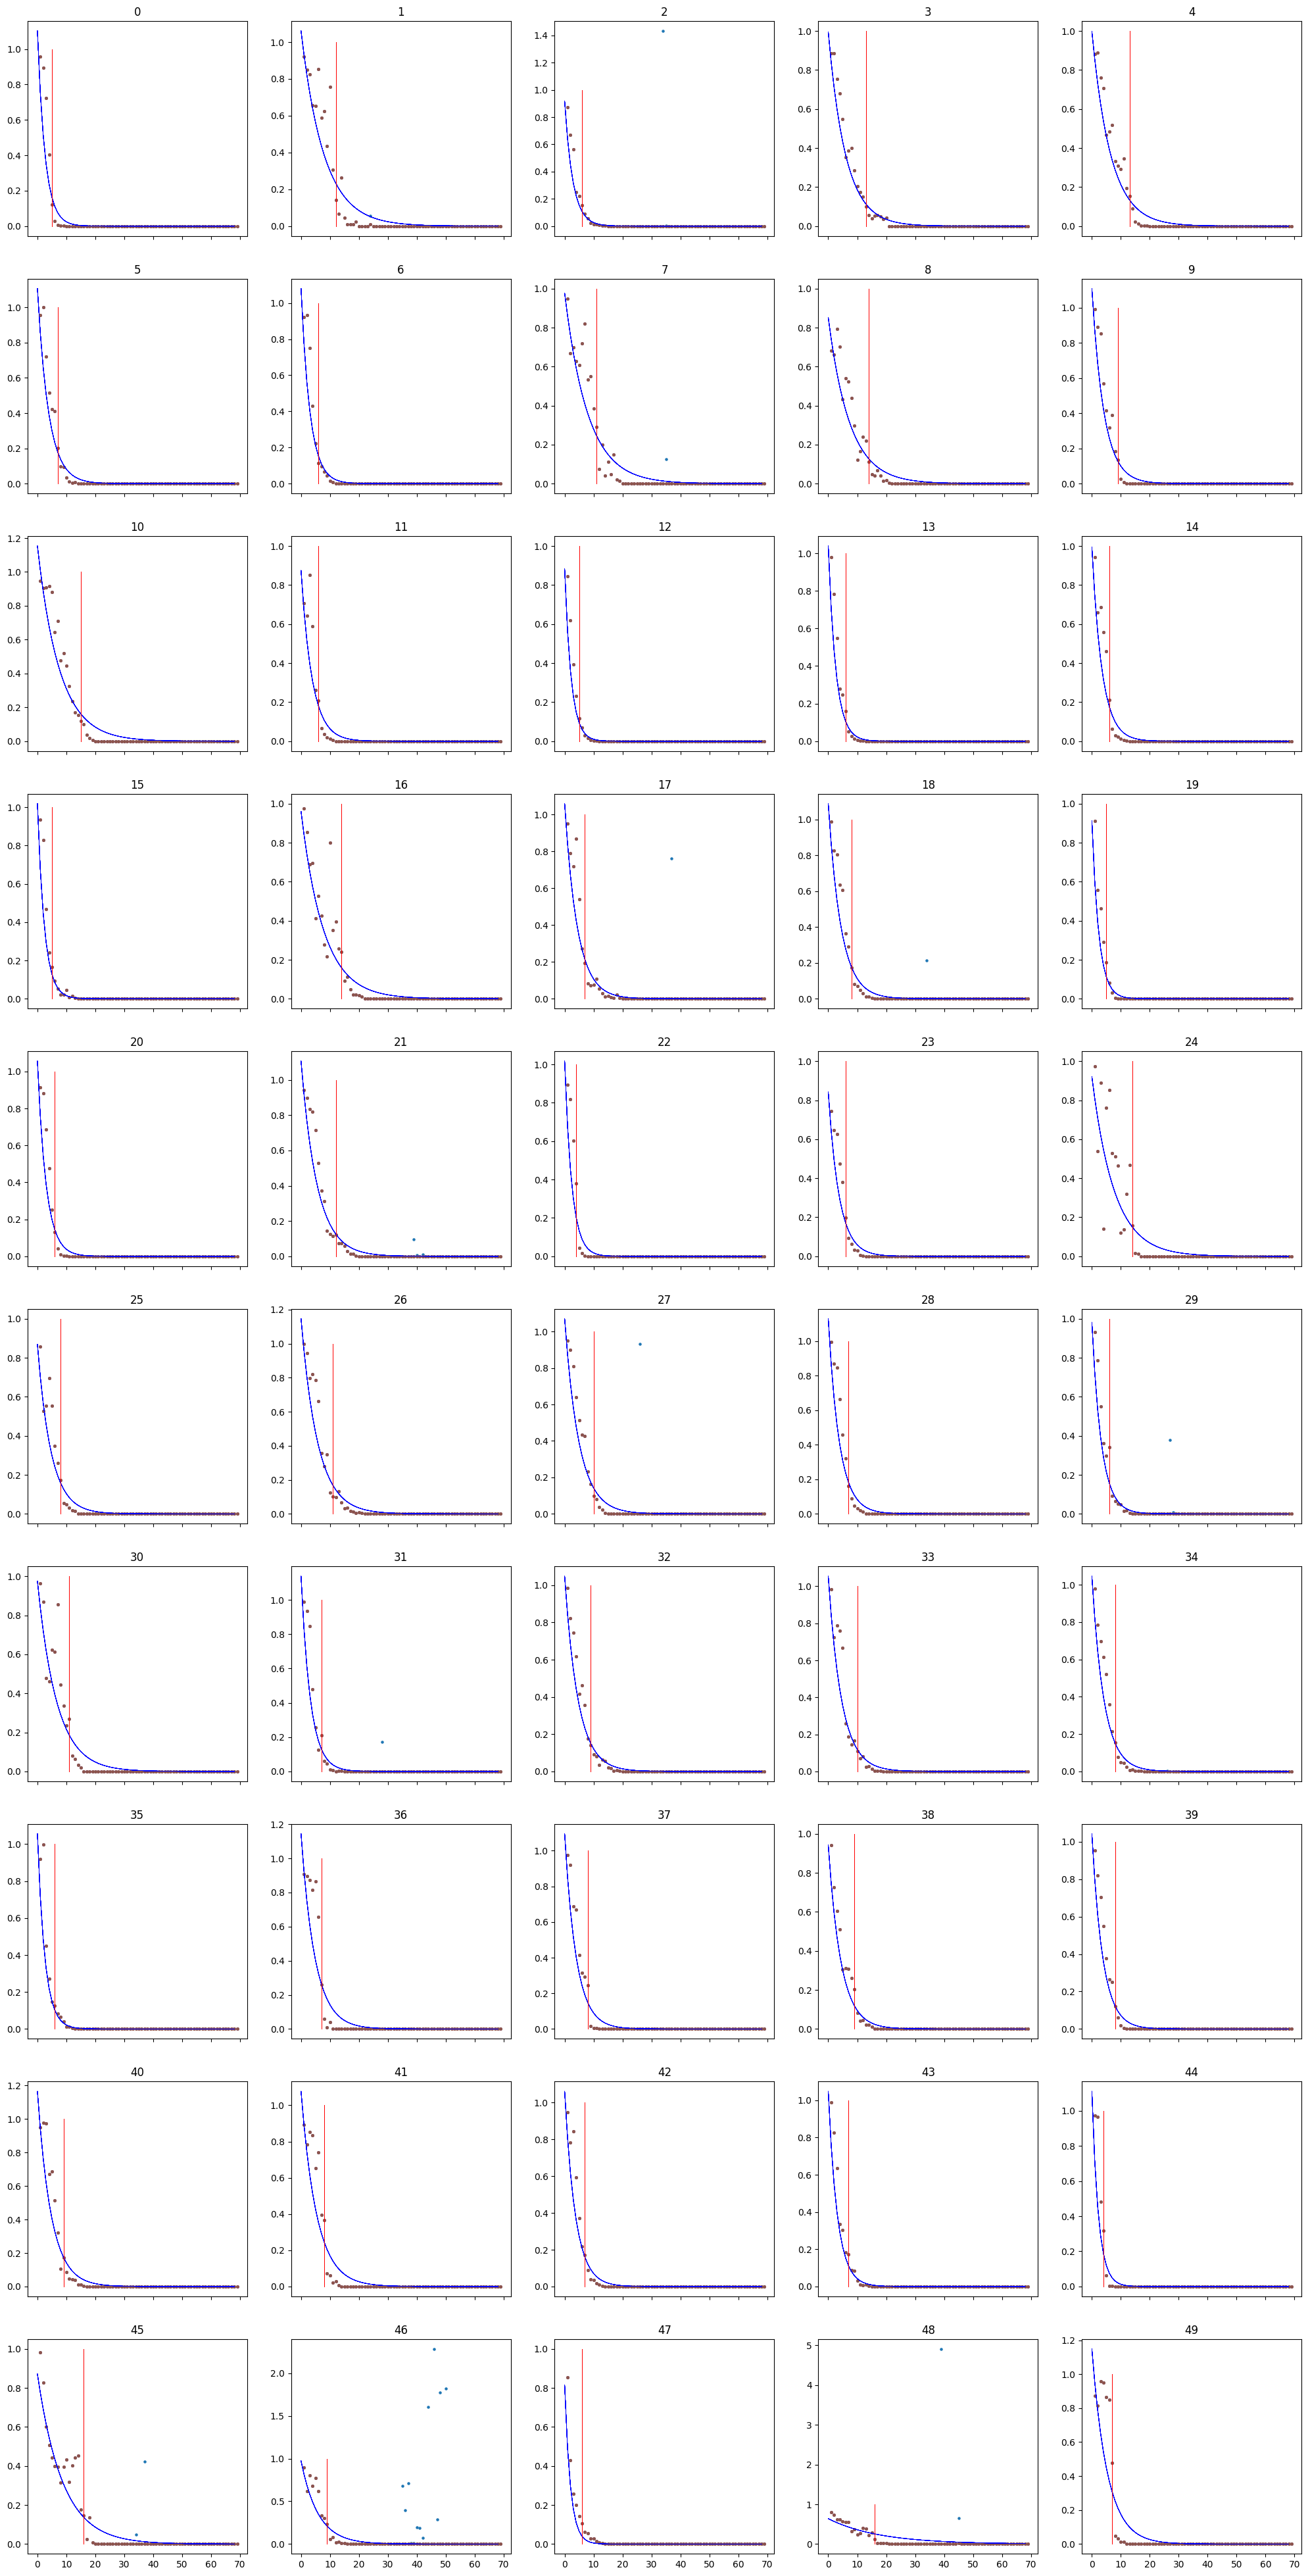

In [10]:
# plot the lengths of the orthogonal vectors
fig, ax = plt.subplots(10,5, figsize=(25,50), sharex=True)
for t in range(50):
    for i in range(Hippo_n_feature):
        ax[t//5, t%5].scatter(x_vals, orth_vec_lens[t, i, :], label=f'{i}', s=5)
        ax[t//5, t%5].plot(y_vals[t, :], c='b',linewidth=0.5)
        ax[t//5, t%5].set_title(f'{t}')
        ax[t//5, t%5].vlines(thresh_crossed[t], ymin=0, ymax=1, colors='r', linewidths=0.5)

In [11]:
trials = [14, 23, 39, 45, 46, 47, 49]
for t in trials:
    #print(f'threshhold was crossed in trial {t}: {thresh_crossed[t]}')
    print(thresh_crossed[t])
    #print(f'tau in trial {t} was: {tau_vals[t]}')
    print(tau_vals[t])

6.0
3.488209166409116
6.0
3.763569403779352
8.0
3.748578185565257
16.0
8.661722384927877
9.0
5.871435089052026
6.0
1.9867867065673306
7.0
5.317733469527446


In [13]:
neuron_norms_for_srs = np.zeros((50, time_steps))

for t in range(50):
    #for i in range(Hippo_n_feature):
    hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=0, weights_folder='weights_shrunk_esn_sr1.4')
      
    neuron_norms_for_srs[t, :] = hs.norm(dim=1)
        

In [14]:
# get the trials sorted by their tau values and threshold crossing times
idx_sorted_tau = np.argsort(-tau_vals)
idx_sorted_thresh_crossed = np.argsort(-thresh_crossed)

print(idx_sorted_tau)
#print(tau_vals[idx_sorted_tau])
print(idx_sorted_thresh_crossed)
#print(thresh_crossed[idx_sorted_thresh_crossed])

[48 45  7  1 16 24 10  8 30  4  3 46 26 21 41 49 27 36 40 25 32 33 18 17
 38 34  9 37  5 28 11 23 39 42 14 29 31 43  6 20  2 13  0 35 22 15 19 44
 12 47]
[48 45 10  8 24 16  3  4  1 21 26  7 30 33 27  9 38 32 46 40 39 34 41 37
 25 18 17 42 43 28 31  5 49 36 47 11 14  6  2 20 13 23 29 35  0 19 12 15
 22 44]


In [15]:
# see the stable trials sorted by their tau values and threshold crossing times
stable_trials_idx = stable_trials(neuron_norms_for_srs)
print(stable_trials_idx)
print('######################################')

m = np.isin(idx_sorted_tau, stable_trials_idx)
stable_sorted_tau = idx_sorted_tau[m]
print(stable_sorted_tau)

m = np.isin(idx_sorted_thresh_crossed, stable_trials_idx)
stable_sorted_thresh = idx_sorted_thresh_crossed[m]
print(stable_sorted_thresh)

[ 1  3  4  5  7  8  9 10 11 17 18 22 24 25 27 30 32 33 34 35 36 37 38 39
 40 41 43 44 45 46 48 49]
######################################
[48 45  7  1 24 10  8 30  4  3 46 41 49 27 36 40 25 32 33 18 17 38 34  9
 37  5 11 39 43 35 22 44]
[48 45 10  8 24  3  4  1  7 30 33 27  9 38 32 46 40 39 34 41 37 25 18 17
 43  5 49 36 11 35 22 44]


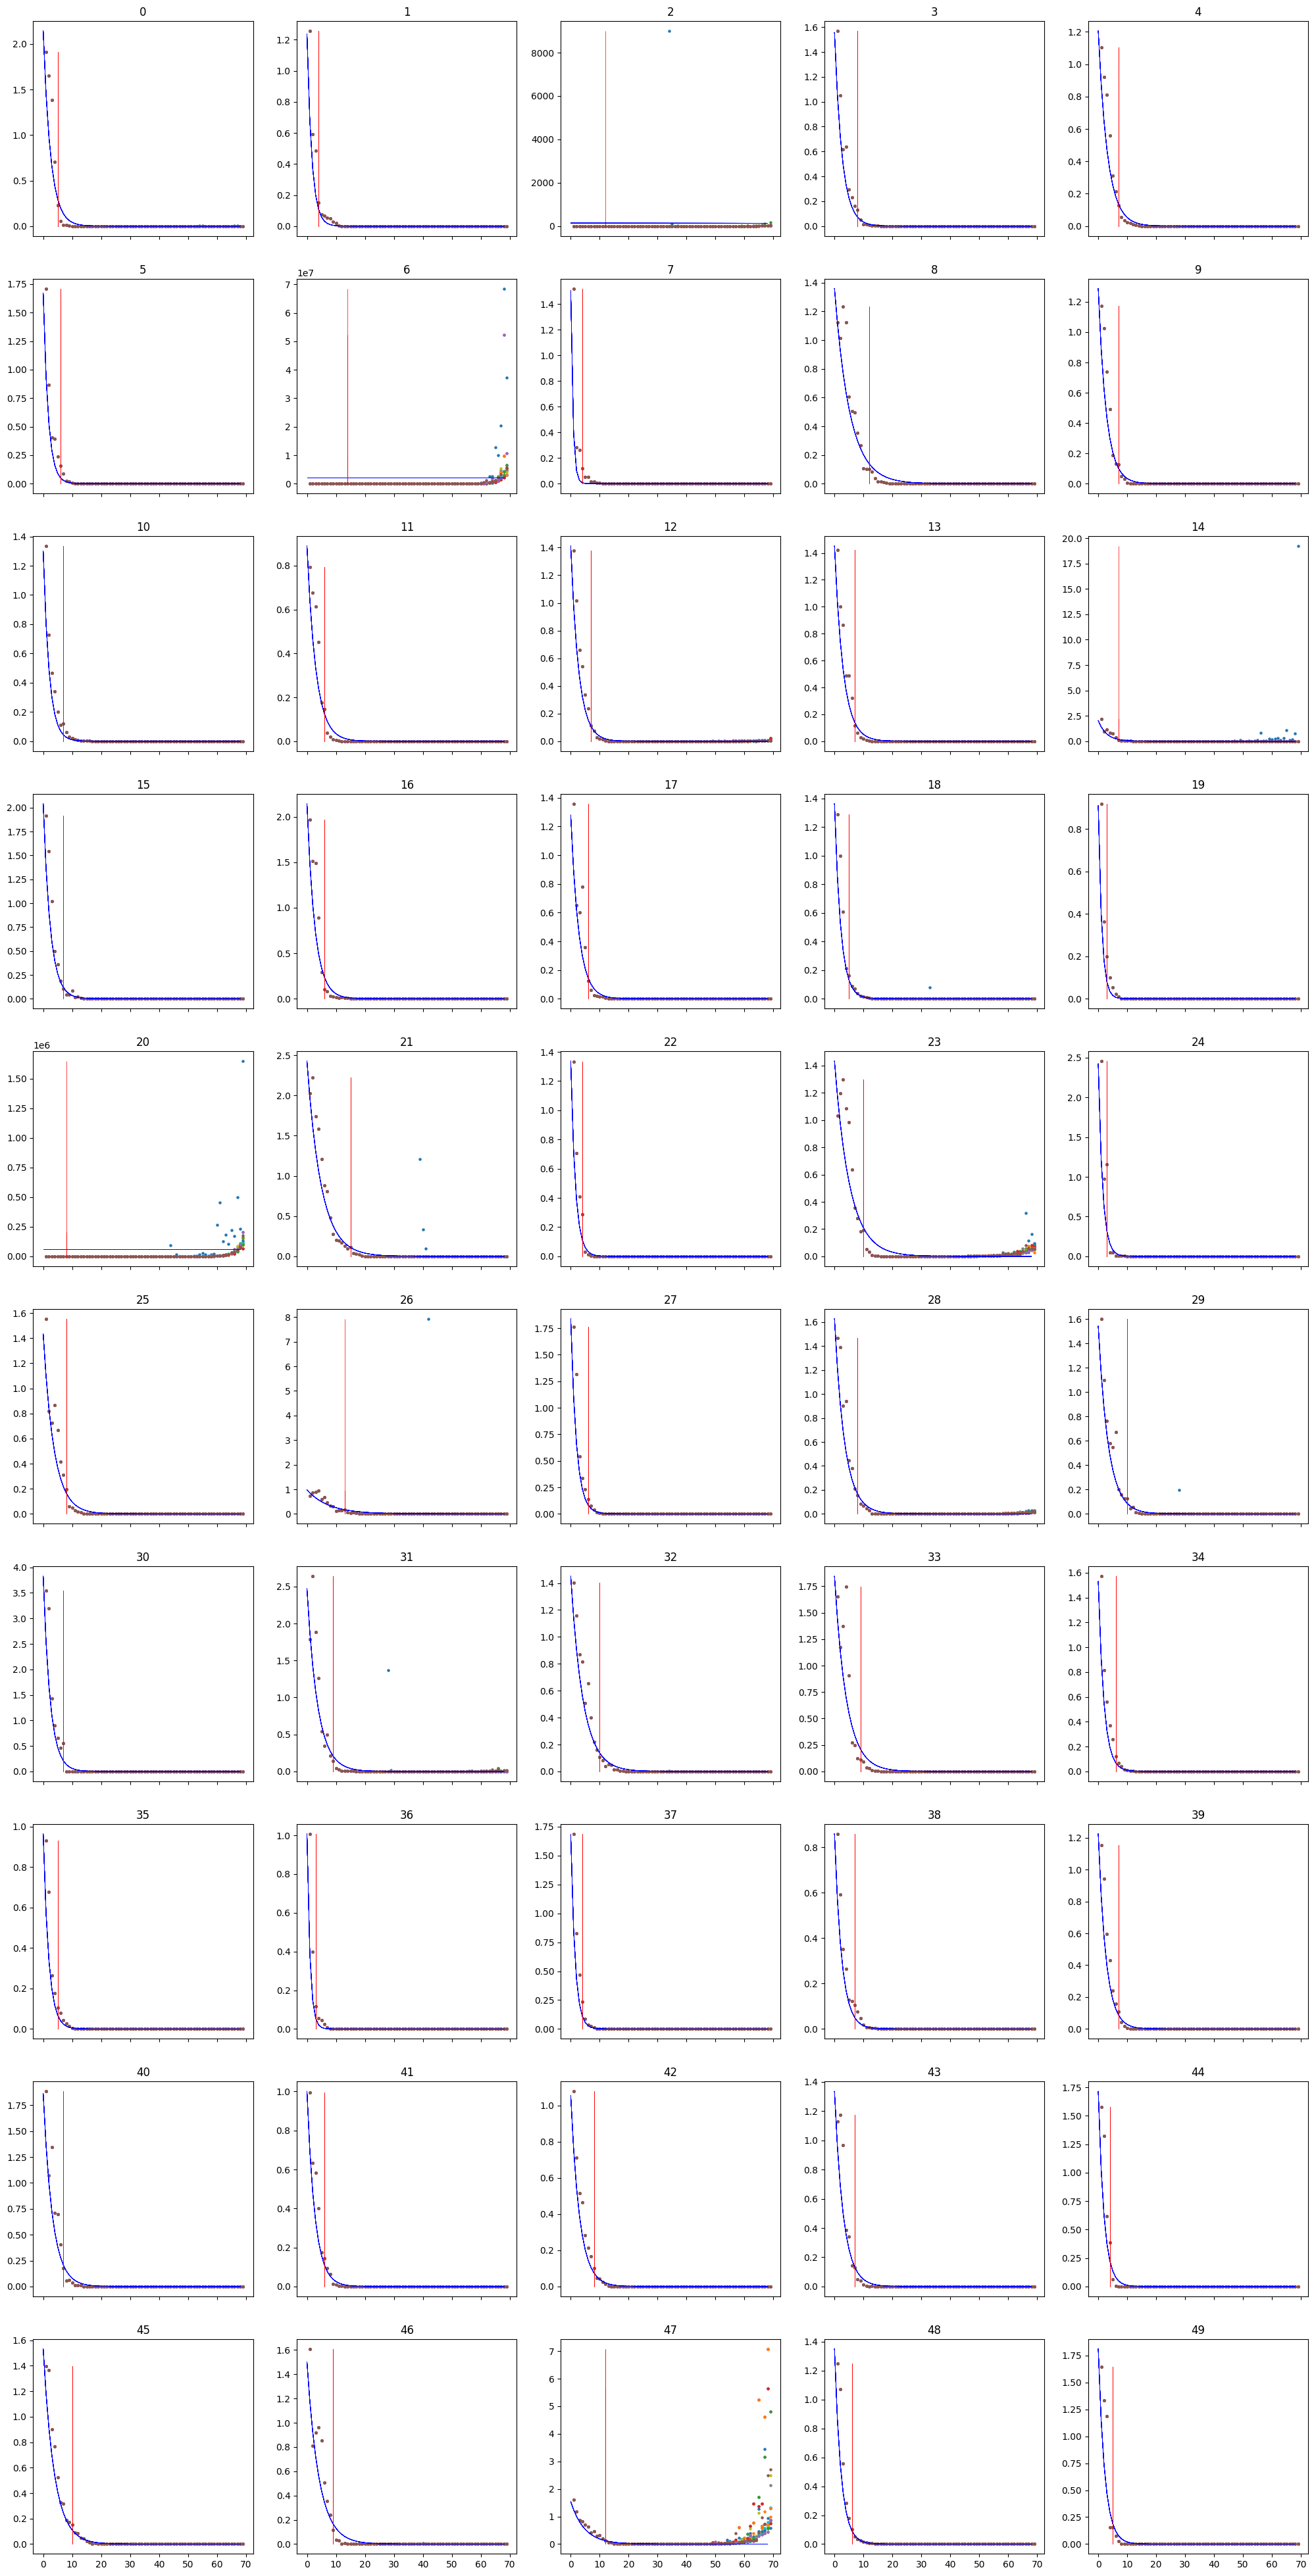

In [16]:
# plot the lengths of the orthogonal vectors but the new vector was not normalized when computing the orthogonal vector
fig, ax = plt.subplots(10,5, figsize=(25,50), sharex=True)
for t in range(50):
    for i in range(Hippo_n_feature):
        ax[t//5, t%5].scatter(x_vals, orth_vec_lens_not_norm[t, i, :], label=f'{i}', s=5)
        ax[t//5, t%5].plot(y_vals_not_norm[t, :], c='b',linewidth=0.5)
        ax[t//5, t%5].set_title(f'{t}')
        ax[t//5, t%5].vlines(thresh_crossed_not_norm[t], ymin=0, ymax=max(orth_vec_lens_not_norm[t, i, :]), colors='r', linewidths=0.5)

In [17]:
# get the trials sorted by their tau values and threshold crossing times
idx_sorted_tau_not_norm = np.argsort(-tau_vals_not_norm)
idx_sorted_thresh_crossed_not_norm = np.argsort(-thresh_crossed_not_norm)

print(idx_sorted_tau_not_norm)
#print(tau_vals[idx_sorted_tau])
print(idx_sorted_thresh_crossed_not_norm)
#print(thresh_crossed[idx_sorted_thresh_crossed])

[ 6 20  2 26  8 23 21 47 32 33 46 45 25 31 28 29  4 40 11 42 43 13 14 17
  9 41 16 12 39  3  0 38 15 30 48 49 18 10 44 34 27 35  5  1 22 37 24 19
 36  7]
[21  6 26  2  8 47 23 29 32 45 33 46 31 28 25 20 42  3 30 15 12 10 43 40
 39 38 13 14  9  4  5 16 11 27 41 34 48 17 18  0 49 35 44  1  7 37 22 19
 24 36]


In [18]:
# see the stable trials sorted by their tau values and threshold crossing times
stable_trials_idx_not_norm = stable_trials(neuron_norms_for_srs)
print(stable_trials_idx_not_norm)
print('######################################')

m_not_norm = np.isin(idx_sorted_tau_not_norm, stable_trials_idx_not_norm)
stable_sorted_tau_not_norm = idx_sorted_tau_not_norm[m_not_norm]
print(stable_sorted_tau_not_norm)

m_not_norm = np.isin(idx_sorted_thresh_crossed_not_norm, stable_trials_idx_not_norm)
stable_sorted_thresh_not_norm = idx_sorted_thresh_crossed_not_norm[m_not_norm]
print(stable_sorted_thresh_not_norm)

[ 1  3  4  5  7  8  9 10 11 17 18 22 24 25 27 30 32 33 34 35 36 37 38 39
 40 41 43 44 45 46 48 49]
######################################
[ 8 32 33 46 45 25  4 40 11 43 17  9 41 39  3 38 30 48 49 18 10 44 34 27
 35  5  1 22 37 24 36  7]
[ 8 32 45 33 46 25  3 30 10 43 40 39 38  9  4  5 11 27 41 34 48 17 18 49
 35 44  1  7 37 22 24 36]


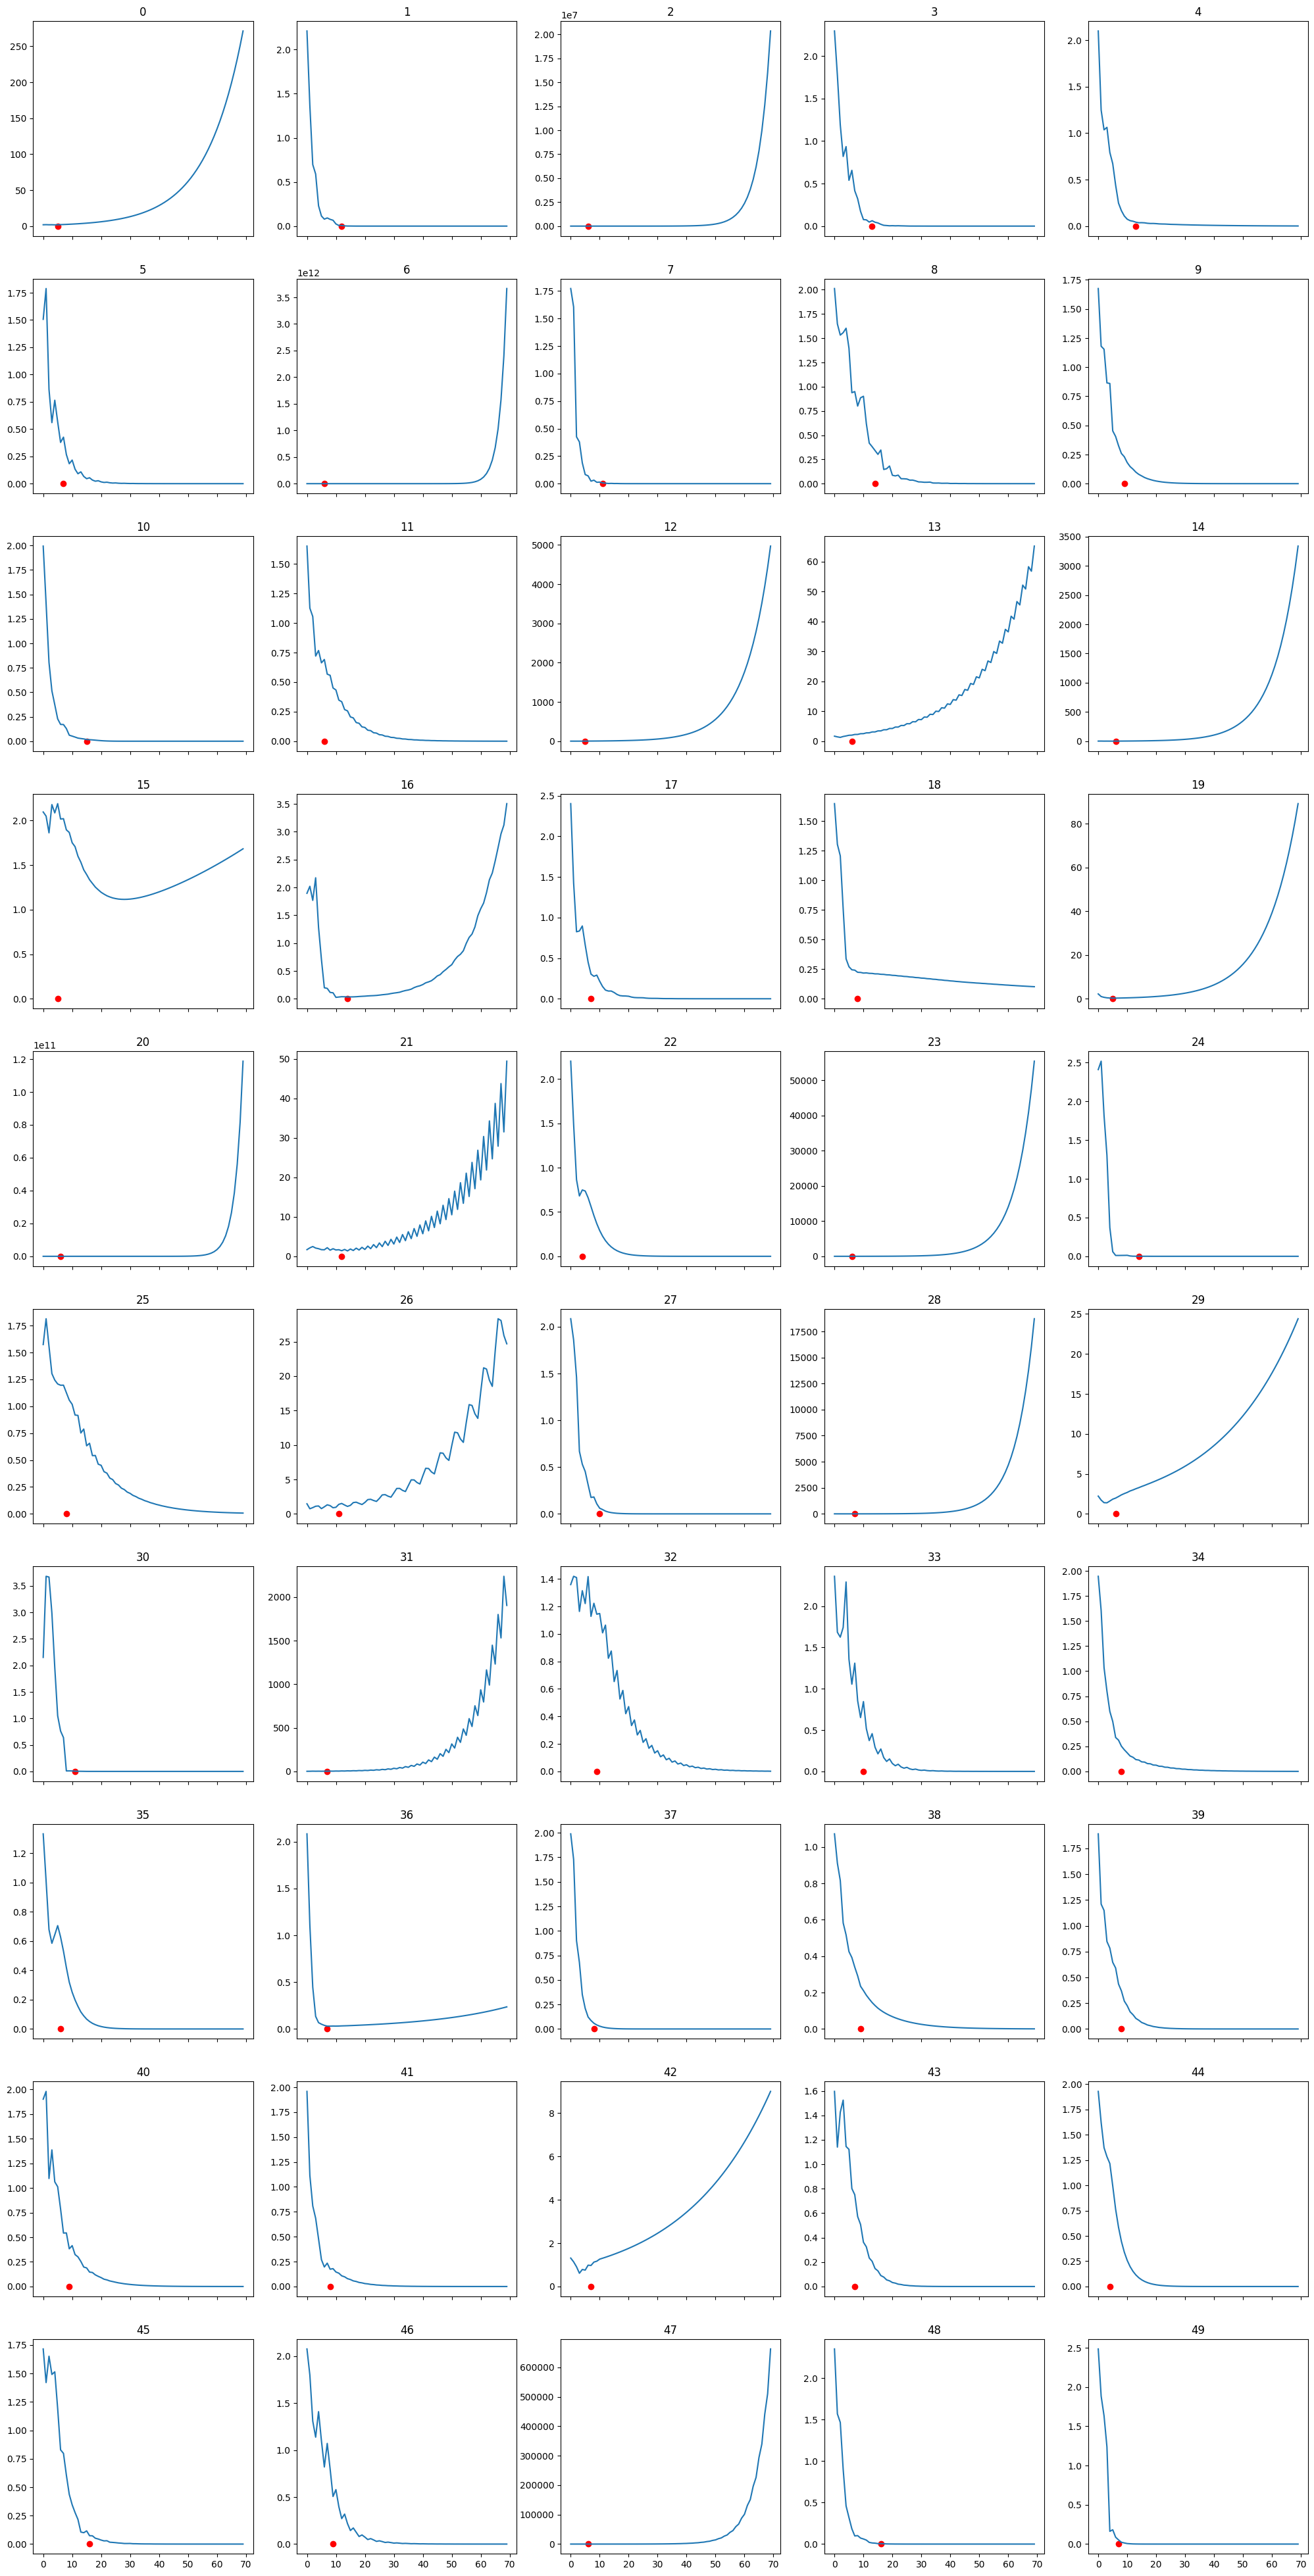

In [19]:
# plot the norms of the different weights
x_vals = np.arange(1,70)
fig, ax = plt.subplots(10,5, figsize=(25,50), sharex=True)
for t in range(50):
    #for i in range(Hippo_n_feature):
    ax[t//5, t%5].plot(neuron_norms_for_srs[t, :])
    ax[t//5, t%5].set_title(f'{t}')
    ax[t//5, t%5].scatter(thresh_crossed[t], 0, c='r')

